<a href="https://colab.research.google.com/github/syakiraocta/Machine-Learning-Classification/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP 1: Import Library

Memanggil library yang diperlukan: numpy untuk angka, matplotlib untuk grafik, dan pandas untuk tabel

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#  STEP 2: Load Dataset


Mengambil data dari file CSV

In [9]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
# Mengambil kolom Umur dan Gaji sebagai input
y = dataset.iloc[:, -1].values
# Mengambil kolom terakhir sebagai target (Purchased)

#  STEP 3: Proses Sampling (Train-Test Split)

Membagi data menjadi dua bagian: 75% untuk melatih model, 25% untuk menguji akurasi (Sampling)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# STEP 4: Feature Scaling

Menyamakan skala data karena rentang umur dan gaji sangat berbeda agar model bekerja lebih optimal

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# STEP 5: Menjalankan Model K-NN

Menggunakan 5 tetangga terdekat (K=5) dengan metode jarak Euclidean

In [12]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)


KNeighborsClassifier()

#  STEP 6: Melakukan Prediksi

Menjalankan prediksi pada data uji (test set) untuk melihat kemampuan model

In [13]:
y_pred = classifier.predict(X_test)


# STEP 7: Evaluasi Hasil

Membuat Confusion Matrix dan menghitung persentase akurasi tebakan model

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"Akurasi Model dengan K=7: {accuracy_score(y_test, y_pred) * 100}%")

Confusion Matrix:
[[64  4]
 [ 3 29]]
Akurasi Model dengan K=7: 93.0%


# STEP 8: Menampilkan Grafik Hasil Uji

Menampilkan grafik pembagi wilayah untuk membedakan kategori "Membeli" (hijau) dan "Tidak" (merah)

/tmp/ipykernel_1117/3336199684.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


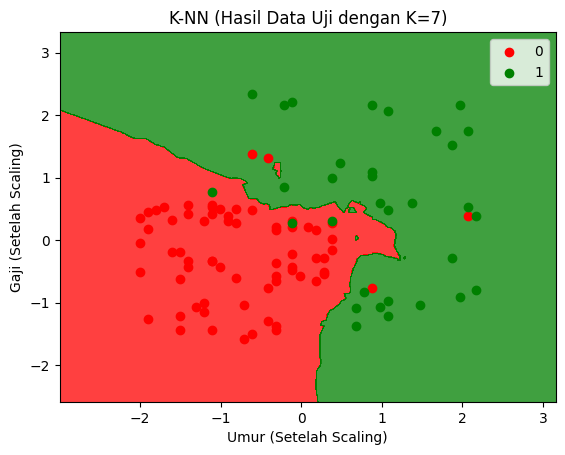

In [15]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Hasil Data Uji dengan K=7)')
plt.xlabel('Umur (Setelah Scaling)')
plt.ylabel('Gaji (Setelah Scaling)')
plt.legend()
plt.show()